# **Preprocessing**

In [ ]:
# 1. Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset
df = pd.read_csv("survey.csv")  # Ganti path jika perlu
print("Ukuran dataset:", df.shape)
df.head()


Ukuran dataset: (1259, 27)


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [ ]:
# 3. Informasi Dataset
df.info()
df.describe(include='all')  # Termasuk kolom non-numerik


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
count,1259,1.259000e+03,1259,1259,744,1241,1259,1259,995,1259,...,1259,1259,1259,1259,1259,1259,1259,1259,1259,164
unique,1246,NaN,49,48,45,2,2,2,4,6,...,5,3,3,3,3,3,3,3,2,160
top,2014-08-27 12:31:41,NaN,Male,United States,CA,No,No,Yes,Sometimes,6-25,...,Don't know,No,No,Some of them,Yes,No,Maybe,Don't know,No,* Small family business - YMMV.
freq,2,NaN,615,751,138,1095,767,637,465,290,...,563,490,925,774,516,1008,557,576,1075,5
mean,NaN,7.942815e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,2.818299e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,-1.726000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2.700000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,3.100000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,3.600000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 4. Cek Missing Values
missing = df.isnull().sum().sort_values(ascending=False)
print("Jumlah missing value per kolom:")
print(missing[missing > 0])


Jumlah missing value per kolom:
comments          1095
state              515
work_interfere     264
self_employed       18
dtype: int64


In [ ]:
# 5. Pembersihan Data (Contoh Sederhana)
# - Normalisasi gender (banyak variasi input)
def clean_gender(g):
    g = str(g).lower()
    if "female" in g:
        return "Female"
    elif "male" in g:
        return "Male"
    else:
        return "Other"

df["Gender"] = df["Gender"].apply(clean_gender)

# - Hapus baris dengan terlalu banyak missing
df = df.dropna(thresh=len(df.columns) * 0.7)  # buang baris jika >30% data hilang


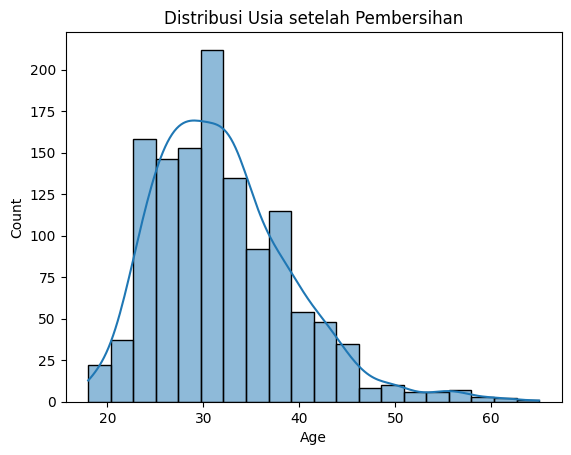

In [ ]:
# 6. Filter nilai usia yang masuk akal (misalnya 15–65)
df = df[(df['Age'] >= 15) & (df['Age'] <= 65)]

# Lihat distribusi usia
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Distribusi Usia setelah Pembersihan")
plt.show()


In [ ]:
# 7. Cek dan tangani missing values (sementara drop baris dengan NA)
missing = df.isnull().sum()
print("Kolom dengan missing value:")
print(missing[missing > 0])

# Drop baris yang mengandung NA hanya di kolom penting
essential_cols = ['Gender', 'Age', 'mental_health_consequence', 'seek_help', 'wellness_program']
df = df.dropna(subset=essential_cols)

print("Dimensi setelah pembersihan:", df.shape)


Kolom dengan missing value:
state              513
self_employed       18
work_interfere     262
comments          1089
dtype: int64
Dimensi setelah pembersihan: (1250, 27)


In [ ]:
# 8. Preview data yang sudah dibersihkan
df[essential_cols].head()


,Gender,Age,mental_health_consequence,seek_help,wellness_program
0,Female,37,No,Yes,No
1,Other,44,Maybe,Don't know,Don't know
2,Male,32,No,No,No
3,Male,31,Yes,No,No
4,Male,31,No,Don't know,Don't know


# **PERTANYAAN 1**
## Apakah terdapat hubungan antara gender dan kemungkinan mengalami gangguan kesehatan mental di industri teknologi?

Variabel:
Gender → Kategori: Male, Female, Other

mental_health_consequence → Kategori: "Yes", "Maybe", "No

### Langkah Analisis:

Buat tabulasi silang (contingency table)

Visualisasi distribusi

Lakukan uji Chi-Square

Interpretasi hasil (apakah p-value < 0.05?)

In [ ]:
from scipy.stats import chi2_contingency

# 1. Tabulasi silang
ct = pd.crosstab(df['Gender'], df['mental_health_consequence'])
print("Tabel Kontingensi:")
print(ct)


Tabel Kontingensi:
mental_health_consequence  Maybe   No  Yes
Gender                                    
Female                        84   53   53
Male                         302  344  181
Other                         89   90   54


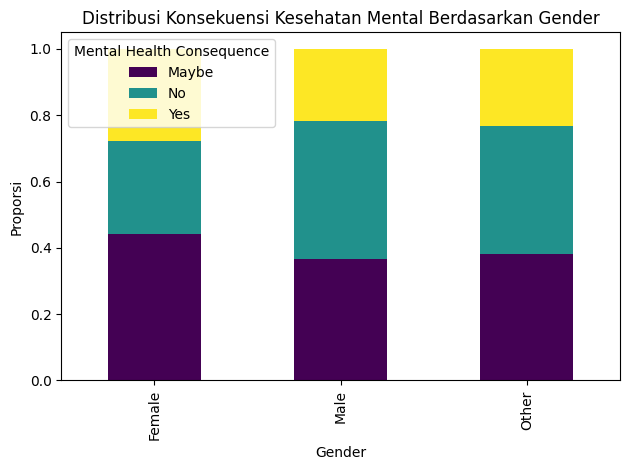

In [ ]:
# 2. Visualisasi
ct_norm = ct.div(ct.sum(axis=1), axis=0)  # Normalisasi per baris
ct_norm.plot(kind='bar', stacked=True, colormap='viridis')
plt.title("Distribusi Konsekuensi Kesehatan Mental Berdasarkan Gender")
plt.ylabel("Proporsi")
plt.xlabel("Gender")
plt.legend(title="Mental Health Consequence")
plt.tight_layout()
plt.show()


In [ ]:
# 3. Uji Chi-Square
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")

if p < 0.05:
    print("✅ Terdapat hubungan signifikan antara Gender dan Konsekuensi Kesehatan Mental.")
else:
    print("❌ Tidak terdapat hubungan signifikan antara Gender dan Konsekuensi Kesehatan Mental.")


Chi-Square Statistic: 12.2853
P-value: 0.0154
✅ Terdapat hubungan signifikan antara Gender dan Konsekuensi Kesehatan Mental.


# **PERTANYAAN 2**
Apakah usia memengaruhi kemungkinan seseorang mengalami gangguan kesehatan mental?

## Variabel:
Age → numerik

mental_health_consequence → kategorik (Yes, Maybe, No)

## Langkah Analisis:
Kelompokkan responden berdasarkan mental_health_consequence

Visualisasikan distribusi usia per kategori

Lakukan uji ANOVA (karena kita punya >2 grup)

Interpretasi p-value

In [ ]:
import seaborn as sns
from scipy.stats import f_oneway

# 1. Cek jumlah data tiap kelompok
print(df['mental_health_consequence'].value_counts())


mental_health_consequence
No       487
Maybe    475
Yes      288
Name: count, dtype: int64


<ipython-input-206-45abfbb9580f>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='mental_health_consequence', y='Age', data=df, palette='pastel')


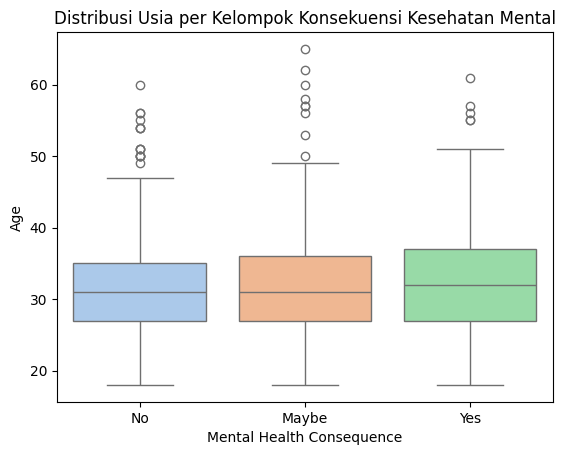

In [ ]:
# 2. Visualisasi distribusi usia per kelompok
sns.boxplot(x='mental_health_consequence', y='Age', data=df, palette='pastel')
plt.title("Distribusi Usia per Kelompok Konsekuensi Kesehatan Mental")
plt.xlabel("Mental Health Consequence")
plt.ylabel("Age")
plt.show()


In [ ]:
# 3. Siapkan data untuk uji ANOVA
group_yes = df[df['mental_health_consequence'] == 'Yes']['Age']
group_maybe = df[df['mental_health_consequence'] == 'Maybe']['Age']
group_no = df[df['mental_health_consequence'] == 'No']['Age']

# 4. Uji ANOVA
f_stat, p_val = f_oneway(group_yes, group_maybe, group_no)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("✅ Usia memiliki perbedaan signifikan antar kelompok konsekuensi kesehatan mental.")
else:
    print("❌ Tidak ada perbedaan signifikan usia antar kelompok.")


F-statistic: 2.9357
P-value: 0.0535
❌ Tidak ada perbedaan signifikan usia antar kelompok.


# **PERTANYAAN 3**
Apakah dukungan perusahaan terhadap kesehatan mental (misalnya program wellness) memengaruhi kemungkinan karyawan mencari bantuan kesehatan mental?

## Variabel:
wellness_program → "Yes", "No", "Don't know"

seek_help → "Yes", "No", "Don't know"

## Langkah Analisis:

Tabulasi silang antara wellness_program dan seek_help

Visualisasi

Uji Chi-Square

Interpretasi hasil

In [ ]:
# 1. Tabel kontingensi
ct2 = pd.crosstab(df['wellness_program'], df['seek_help'])
print("Tabel Kontingensi (Wellness Program vs Seek Help):")
print(ct2)


Tabel Kontingensi (Wellness Program vs Seek Help):
seek_help         Don't know   No  Yes
wellness_program                      
Don't know               138   21   27
No                       185  592   60
Yes                       40   28  159


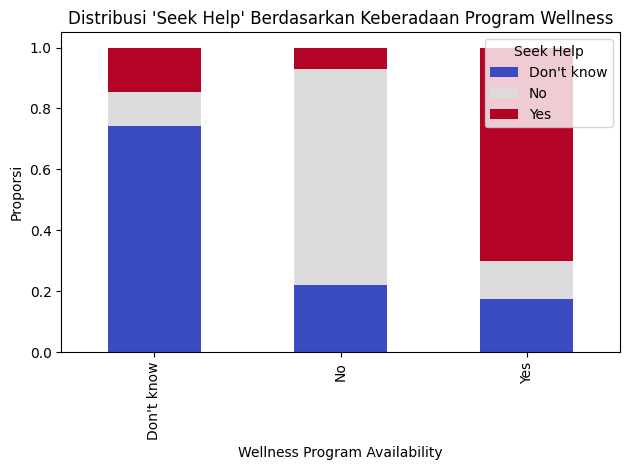

In [ ]:
# 2. Visualisasi
ct2_norm = ct2.div(ct2.sum(axis=1), axis=0)
ct2_norm.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title("Distribusi 'Seek Help' Berdasarkan Keberadaan Program Wellness")
plt.ylabel("Proporsi")
plt.xlabel("Wellness Program Availability")
plt.legend(title="Seek Help")
plt.tight_layout()
plt.show()


In [ ]:
# 3. Uji Chi-Square
chi2_2, p_2, dof_2, expected_2 = chi2_contingency(ct2)
print(f"Chi-Square Statistic: {chi2_2:.4f}")
print(f"P-value: {p_2:.4f}")

if p_2 < 0.05:
    print("✅ Terdapat hubungan signifikan antara dukungan perusahaan dan kecenderungan mencari bantuan.")
else:
    print("❌ Tidak terdapat hubungan signifikan antara keduanya.")


Chi-Square Statistic: 703.2099
P-value: 0.0000
✅ Terdapat hubungan signifikan antara dukungan perusahaan dan kecenderungan mencari bantuan.


# **PERTANYANN 4**
Prediksi kemungkinan seek help berdasarkan variabel-variabel

## Tujuan:
Memprediksi apakah seseorang akan mencari bantuan kesehatan mental (seek_help) berdasarkan faktor-faktor seperti usia, gender, dan dukungan perusahaan.

## Langkah:
Seleksi & encoding fitur yang relevan

Split data (train-test)

Bangun model klasifikasi (Logistic Regression atau Decision Tree)

Evaluasi akurasi

Visualisasi pohon keputusan (jika pakai Decision Tree)



In [ ]:
from sklearn.preprocessing import LabelEncoder

# Salin dataframe agar tidak merusak df asli
df_model = df.copy()

# Pilih fitur dan target
features = ['Age', 'Gender', 'wellness_program']
target = 'seek_help'

# Encode semua kolom kategorik
le = LabelEncoder()
for col in features + [target]:
    df_model[col] = le.fit_transform(df_model[col])

df_model[features + [target]].head()


,Age,Gender,wellness_program,seek_help
0,19,0,1,2
1,26,2,0,0
2,14,1,1,1
3,13,1,1,1
4,13,1,0,0


In [ ]:
from sklearn.model_selection import train_test_split

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("=== Logistic Regression ===")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


=== Logistic Regression ===
[[ 29  40  11]
 [  3 117   4]
 [  7   6  33]]
              precision    recall  f1-score   support

           0       0.74      0.36      0.49        80
           1       0.72      0.94      0.82       124
           2       0.69      0.72      0.70        46

    accuracy                           0.72       250
   macro avg       0.72      0.67      0.67       250
weighted avg       0.72      0.72      0.69       250



In [ ]:
print(df_model['seek_help'].unique())


[2 0 1]


=== Decision Tree ===
[[ 29  40  11]
 [  3 117   4]
 [  6   6  34]]
              precision    recall  f1-score   support

           0       0.76      0.36      0.49        80
           1       0.72      0.94      0.82       124
           2       0.69      0.74      0.72        46

    accuracy                           0.72       250
   macro avg       0.72      0.68      0.67       250
weighted avg       0.73      0.72      0.69       250



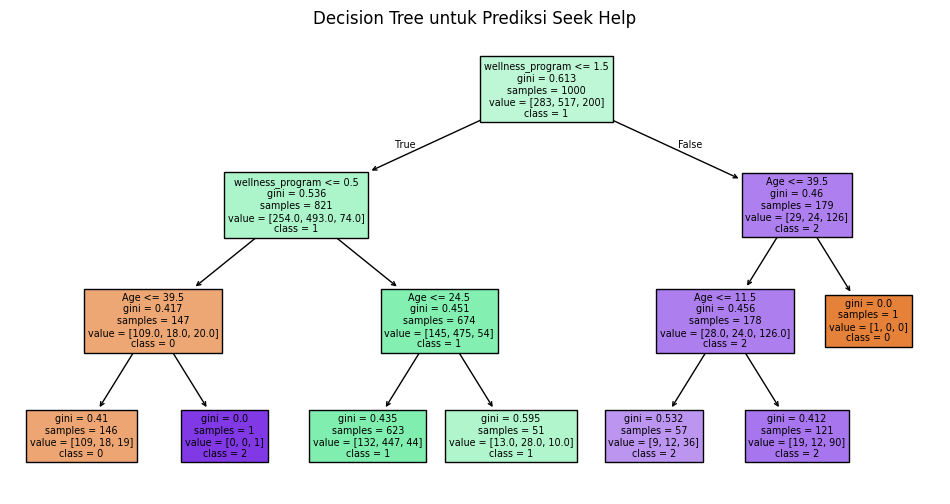

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from imblearn.over_sampling import SMOTE


tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("=== Decision Tree ===")
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

# Visualisasi
# Ambil label unik dari target
import numpy as np

label_kelas = np.unique(y_train)  # misalnya [0, 1, 2]
class_labels = [str(cls) for cls in label_kelas]  # bisa juga manual ['No', 'Yes', "Don't know"] jika tahu urutannya

# Visualisasi tree dengan jumlah label yang sesuai
plt.figure(figsize=(12, 6))
plot_tree(tree_model, feature_names=features, class_names=class_labels, filled=True)
plt.title("Decision Tree untuk Prediksi Seek Help")
plt.show()



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Inisialisasi dan training model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf_model.predict(X_test)

# Evaluasi
print("=== Random Forest ===")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


=== Random Forest ===
[[ 30  40  10]
 [  4 117   3]
 [  7   6  33]]
              precision    recall  f1-score   support

           0       0.73      0.38      0.50        80
           1       0.72      0.94      0.82       124
           2       0.72      0.72      0.72        46

    accuracy                           0.72       250
   macro avg       0.72      0.68      0.68       250
weighted avg       0.72      0.72      0.70       250



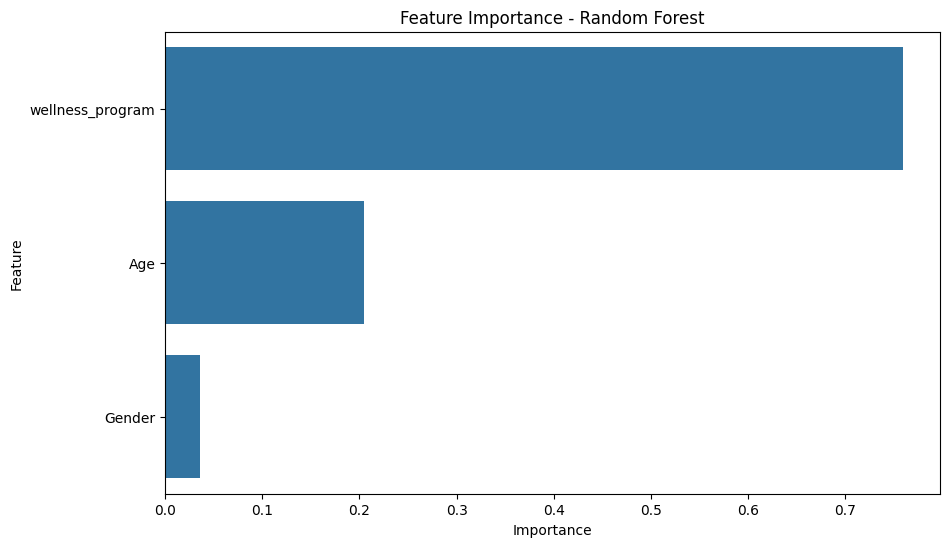

In [ ]:
# Visualisasi feature importance
import seaborn as sns

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importance - Random Forest")
plt.show()


## Coba dengan data baru